## 04. Unit Conversion

In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
import sys
sys.path.append("/Workspace/Users/kimjylin@gmail.com/ca_gas_supply_trends/src")
from unit_converter import e3m3d_to_mtpa, calculate_yoy_mtpa, add_yoy_regime, classify_growth
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [0]:
BASE_PATH = "/Workspace/Users/kimjylin@gmail.com/ca_gas_supply_trends"
CSV_FILE = f"{BASE_PATH}/data/processed/canadian_marketable_gas_2000_25_103m3d.csv"

df = pd.read_csv(CSV_FILE)
df.head()

,Year,Month,Province,Production_e3m3d
0,2000,January,Alberta,387095.0
1,2000,January,British Columbia,54389.0
2,2000,January,Canada Total,463099.0
3,2000,January,NWT & Yukon,1783.0
4,2000,January,New Brunswick,0.0


We focus on Canada Total to analyze national-level structural trends rather than regional fluctuations.

In [0]:
# Keep Canada Total only
annual_df = df[df["Province"] == "Canada Total"].copy()

# If Month is string, convert to numeric
if annual_df["Month"].dtype == object:
    annual_df["Month"] = pd.to_datetime(annual_df["Month"], format='%B').dt.month

# Create datetime for monthly plotting if needed
annual_df["Date"] = pd.to_datetime(dict(year=annual_df["Year"], month=annual_df["Month"], day=1))
annual_df = annual_df.sort_values("Date").reset_index(drop=True)

annual_df.head()

,Year,Month,Province,Production_e3m3d,Date
0,2000,1,Canada Total,463099.0,2000-01-01
1,2000,2,Canada Total,470450.0,2000-02-01
2,2000,3,Canada Total,474403.0,2000-03-01
3,2000,4,Canada Total,481287.0,2000-04-01
4,2000,5,Canada Total,472605.0,2000-05-01


In [0]:
# Annual aggregation
annual_df = annual_df.groupby("Year")["Production_e3m3d"].mean().reset_index()

annual_df.head()

,Year,Production_e3m3d
0,2000,473329.500000
1,2001,494688.250000
2,2002,490478.666667
3,2003,473534.583333
4,2004,479693.416667


In [0]:
annual_df = e3m3d_to_mtpa(annual_df)
annual_df = calculate_yoy_mtpa(annual_df)
annual_df = add_yoy_regime(annual_df)

### Unit conversion: e3m³/d → mtpa

To directly compare Canadian natural gas production with LNG export capacity (reported in mtpa), daily production volumes (e3m³/d) are converted into million tonnes per annum (mtpa) using an industry-standard LNG conversion factor.

Original Data: Daily production in thousands of cubic meters of natural gas

Conversion Steps:
- Step 1: Convert "thousands of cubic meters" (e3m³) to cubic meters (m³).
- Step 2: Convert daily production to annual production by multiplying by 365 days.
- Step 3: Convert annual production (m³/year) into LNG-equivalent million tonnes per annum (mtpa) using an industry benchmark of 1 mtpa ≈ 1.36 bcm/year.


### Compare to LNG Canada Phase 1 demand

LNG Canada's Phase 1 demand is approximately 14 million tonnes per annum.

In [0]:
LNG_PHASE1_MTPA = 14

This is the annual gas volume required by LNG Canada Phase 1. Comparing production increments with this number shows whether Canada’s new production each year is enough to support the LNG project

In [0]:
# Check if production is enough to meet LNG demand
annual_df["Above_LNG_Demand"] = annual_df["Production_mtpa"] >= LNG_PHASE1_MTPA
print("Recent years production vs LNG Canada Phase 1 demand:")
print(annual_df[["Year", "Production_mtpa", "Above_LNG_Demand"]].tail(10))

Recent years production vs LNG Canada Phase 1 demand:
    Year  Production_mtpa  Above_LNG_Demand
16  2016       116.367301              True
17  2017       118.008884              True
18  2018       122.816640              True
19  2019       119.366585              True
20  2020       117.242451              True
21  2021       122.451305              True
22  2022       131.525804              True
23  2023       136.262887              True
24  2024       139.454177              True
25  2025       143.507667              True


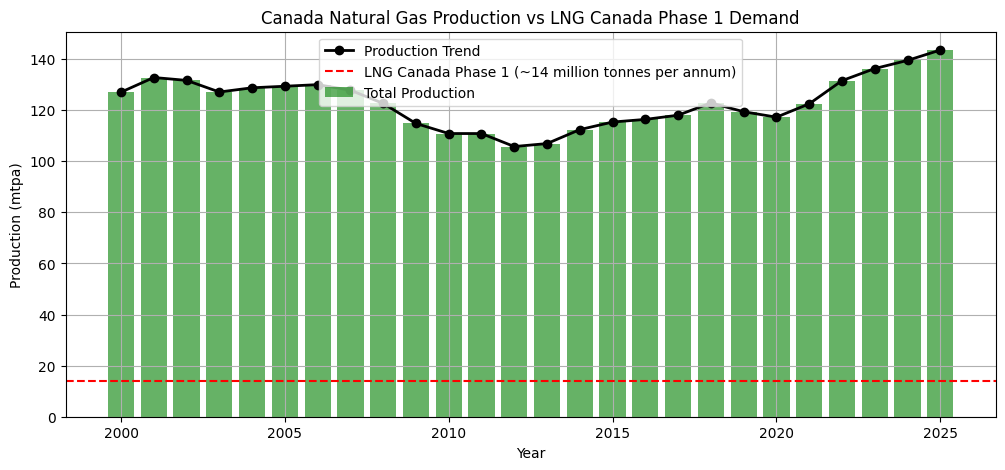

In [0]:
colors = annual_df["Above_LNG_Demand"].map({True: "green", False: "red"})

plt.figure(figsize=(12,5))

# 1. Total production as bar (with color indicating above/below LNG demand)
plt.bar(
    annual_df["Year"],
    annual_df["Production_mtpa"],
    color=colors,
    alpha=0.6,
    label="Total Production"
)

# 2. Overlay line for production trend
plt.plot(
    annual_df["Year"],
    annual_df["Production_mtpa"],
    marker="o",
    color="black",
    linewidth=2,
    label="Production Trend"
)

# 3. Red dashed line for LNG Phase 1 demand
plt.axhline(
    LNG_PHASE1_MTPA,
    color="red",
    linestyle="--",
    label="LNG Canada Phase 1 (~14 million tonnes per annum)"
)

plt.title("Canada Natural Gas Production vs LNG Canada Phase 1 Demand")
plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.grid(True)

# Merge legends for bar, line, and reference
plt.legend()
plt.show()


Each bar represents total annual marketable natural gas production in Canada. 
The red dashed line indicates the estimated LNG Canada Phase 1 feedgas requirement (~14 million tonnes per annum). 
Green bars highlight years in which production levels were above this benchmark. 

While total production may exceed the LNG requirement in many years, actual LNG feasibility depends on the availability of incremental surplus relative to **domestic consumption** and **export commitments**.


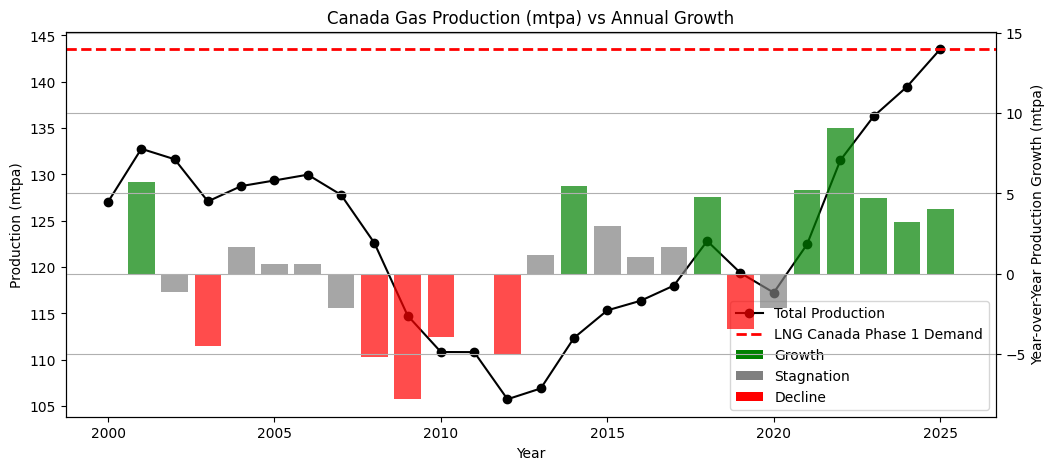

In [0]:
def classify_growth(x):
    if x > 3:
        return "Growth"
    elif x < -3:
        return "Decline"
    else:
        return "Stagnation"

annual_df["YoY_Regime"] = annual_df["YoY_mtpa"].apply(classify_growth)

color_map = {
    "Growth": "green",
    "Stagnation": "gray",
    "Decline": "red"
}
colors = annual_df["YoY_Regime"].map(color_map)

fig, ax1 = plt.subplots(figsize=(12,5))

# Total production (level)
ax1.plot(
    annual_df["Year"],
    annual_df["Production_mtpa"],
    color="black",
    marker="o",
    label="Total Production"
)
ax1.set_ylabel("Production (mtpa)")
ax1.set_xlabel("Year")

# YoY increment bars (growth)
ax2 = ax1.twinx()
ax2.bar(
    annual_df["Year"],
    annual_df["YoY_mtpa"],
    color=colors,
    alpha=0.7,
    # label="YoY Production Growth"
)
ax2.set_ylabel("Year-over-Year Production Growth (mtpa)")

# 🔴 LNG Canada Phase 1 demand line (increment benchmark)
ax2.axhline(
    LNG_PHASE1_MTPA,
    color="red",
    linestyle="--",
    linewidth=2,
    label="LNG Canada Phase 1 Demand"
)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

regime_patches = [
    Patch(facecolor="green", label="Growth"),
    Patch(facecolor="gray", label="Stagnation"),
    Patch(facecolor="red", label="Decline")
]

ax1.legend(
    handles=handles1 + handles2 + regime_patches,
    labels=labels1 + labels2 + [p.get_label() for p in regime_patches],
    loc="lower right"
)

plt.title("Canada Gas Production (mtpa) vs Annual Growth")
plt.grid(True)
plt.show()


The black line shows total annual gas production in Canada, revealing the long-term trend. The bars show the year-over-year change, i.e., how production increased or decreased compared with the previous year Together, the chart helps us see both the overall scale of production and the year-to-year growth, and which years experienced strong growth, decline, or stagnation.

In [0]:
annual_df["YoY_mtpa"].std()

np.float64(4.201489830384181)